# Job Role → Skills: Cleaning, Analysis & Recommendation

This notebook walks through a small end-to-end pipeline:

1. **Generate** a sample dataset mapping job roles to their required skills
2. **Clean** the raw data (fix casing, whitespace, duplicates) into an analysis-ready format
3. **Analyze** which skills are most in-demand across roles
4. **Recommend** job roles for a given set of user skills using TF-IDF + cosine similarity

This is the notebook version of the standalone `.py` scripts in this repo
(`generate_data.py`, `clean_skills.py`, `analyze_skills.py`, `recommend.py`) —
useful for walking through the logic interactively or presenting results inline.


## 0. Setup

Install dependencies if needed:
```bash
pip install -r requirements.txt
```


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

pd.set_option("display.max_colwidth", None)


## 1. Generate the raw dataset

A sample dataset of 10 tech job roles, each with a comma-separated string of
required skills. In a real project you'd swap this for scraped job postings
or a public dataset — the rest of the pipeline doesn't care where the raw
CSV came from, as long as it has `job_role` and `skills` columns.


In [2]:
def build_raw_dataframe() -> pd.DataFrame:
    """Return the raw job_role -> skills sample DataFrame."""
    data = {
        "job_role": [
            "Software Engineer",
            "Data Scientist",
            "DevOps Engineer",
            "Cloud Architect",
            "Machine Learning Engineer",
            "Frontend Developer",
            "Backend Developer",
            "Cybersecurity Analyst",
            "Product Manager",
            "Project Manager",
        ],
        "skills": [
            "Python, Java, C++, Algorithms, Data Structures, Git, Agile",
            "Python, R, SQL, Machine Learning, Statistics, Data Visualization, Pandas, Scikit-learn, TensorFlow",
            "Linux, Docker, Kubernetes, AWS, Azure, CI/CD, Scripting, Python, Bash",
            "AWS, Azure, GCP, Cloud Computing, Networking, Security, Solution Architecture, IaC",
            "Python, TensorFlow, PyTorch, Machine Learning, Deep Learning, NLP, Computer Vision, MLOps",
            "JavaScript, React, Angular, Vue.js, HTML, CSS, UI/UX, Git, Web Development",
            "Python, Java, Node.js, REST APIs, Databases, Microservices, Cloud, Git",
            "Network Security, Incident Response, SIEM, Ethical Hacking, Compliance, Cryptography, Firewalls",
            "Product Management, Market Research, User Stories, Agile, Roadmapping, Stakeholder Management",
            "Project Management, Scrum, Agile, Risk Management, Budgeting, Communication, Leadership",
        ],
    }
    if len(data["job_role"]) != len(data["skills"]):
        raise ValueError("job_role and skills lists must be the same length.")
    return pd.DataFrame(data)


df_raw = build_raw_dataframe()
df_raw.to_csv("data/raw_skills.csv", index=False, encoding="utf-8")
df_raw

,job_role,skills
0,Software Engineer,"Python, Java, C++, Algorithms, Data Structures, Git, Agile"
1,Data Scientist,"Python, R, SQL, Machine Learning, Statistics, Data Visualization, Pandas, Scikit-learn, TensorFlow"
2,DevOps Engineer,"Linux, Docker, Kubernetes, AWS, Azure, CI/CD, Scripting, Python, Bash"
3,Cloud Architect,"AWS, Azure, GCP, Cloud Computing, Networking, Security, Solution Architecture, IaC"
4,Machine Learning Engineer,"Python, TensorFlow, PyTorch, Machine Learning, Deep Learning, NLP, Computer Vision, MLOps"
5,Frontend Developer,"JavaScript, React, Angular, Vue.js, HTML, CSS, UI/UX, Git, Web Development"
6,Backend Developer,"Python, Java, Node.js, REST APIs, Databases, Microservices, Cloud, Git"
7,Cybersecurity Analyst,"Network Security, Incident Response, SIEM, Ethical Hacking, Compliance, Cryptography, Firewalls"
8,Product Manager,"Product Management, Market Research, User Stories, Agile, Roadmapping, Stakeholder Management"
9,Project Manager,"Project Management, Scrum, Agile, Risk Management, Budgeting, Communication, Leadership"


## 2. Clean & reshape the data

The raw `skills` column is a single free-text, comma-separated string —
easy to read but awkward to analyze. This step:

- strips whitespace around each skill
- fixes inconsistent casing (`aws` → `AWS`, `tensorflow` → `TensorFlow`, etc.)
- removes duplicate skills within a role and empty entries from stray commas
- reshapes into **long format** (one row per `job_role, skill` pair) and a
  **one-hot matrix** (`job_role` × `skill`), which are both far more useful
  for analysis and modeling than the original string column.


In [3]:
CANONICAL_OVERRIDES = {
    "sql": "SQL", "aws": "AWS", "gcp": "GCP", "ci/cd": "CI/CD",
    "nlp": "NLP", "mlops": "MLOps", "iac": "IaC", "siem": "SIEM",
    "ui/ux": "UI/UX", "rest apis": "REST APIs", "c++": "C++",
    "node.js": "Node.js", "vue.js": "Vue.js", "html": "HTML", "css": "CSS",
    "tensorflow": "TensorFlow", "pytorch": "PyTorch", "scikit-learn": "Scikit-learn",
}


def normalize_skill(raw_skill: str) -> str:
    skill = raw_skill.strip()
    if not skill:
        return ""
    return CANONICAL_OVERRIDES.get(skill.lower(), skill.title())


def to_long_format(df_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df_raw.iterrows():
        role = str(row["job_role"]).strip()
        seen = set()
        for raw_skill in str(row["skills"]).split(","):
            skill = normalize_skill(raw_skill)
            if not skill or skill.lower() in seen:
                continue
            seen.add(skill.lower())
            rows.append({"job_role": role, "skill": skill})
    return pd.DataFrame(rows).sort_values(["job_role", "skill"]).reset_index(drop=True)


def to_skill_matrix(long_df: pd.DataFrame) -> pd.DataFrame:
    matrix = pd.crosstab(long_df["job_role"], long_df["skill"])
    return (matrix > 0).astype(int).reset_index()


long_df = to_long_format(df_raw)
matrix_df = to_skill_matrix(long_df)

long_df.to_csv("data/cleaned_skills.csv", index=False, encoding="utf-8")
matrix_df.to_csv("data/skills_matrix.csv", index=False, encoding="utf-8")

long_df.head(10)

,job_role,skill
0,Backend Developer,Cloud
1,Backend Developer,Databases
2,Backend Developer,Git
3,Backend Developer,Java
4,Backend Developer,Microservices
5,Backend Developer,Node.js
6,Backend Developer,Python
7,Backend Developer,REST APIs
8,Cloud Architect,AWS
9,Cloud Architect,Azure


In [4]:
matrix_df

skill,job_role,AWS,Agile,Algorithms,Angular,Azure,Bash,Budgeting,C++,CI/CD,...,Scrum,Security,Solution Architecture,Stakeholder Management,Statistics,TensorFlow,UI/UX,User Stories,Vue.js,Web Development
0,Backend Developer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Cloud Architect,1,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
2,Cybersecurity Analyst,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Data Scientist,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
4,DevOps Engineer,1,0,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Frontend Developer,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1
6,Machine Learning Engineer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7,Product Manager,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
8,Project Manager,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
9,Software Engineer,0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Exploratory analysis

Which skills show up most often across all roles? Which roles require the
widest range of distinct skills?


In [5]:
top_skills = long_df["skill"].value_counts().head(10)
skills_per_role = long_df.groupby("job_role")["skill"].nunique().sort_values(ascending=False)

print("Top 10 most in-demand skills:")
print(top_skills.to_string())
print()
print("Distinct skill count per role:")
print(skills_per_role.to_string())

Top 10 most in-demand skills:
skill
Python              5
Git                 3
Agile               3
Java                2
AWS                 2
Azure               2
Machine Learning    2
TensorFlow          2
Cloud               1
Databases           1

Distinct skill count per role:
job_role
DevOps Engineer              9
Data Scientist               9
Frontend Developer           9
Backend Developer            8
Cloud Architect              8
Machine Learning Engineer    8
Cybersecurity Analyst        7
Project Manager              7
Software Engineer            7
Product Manager              6


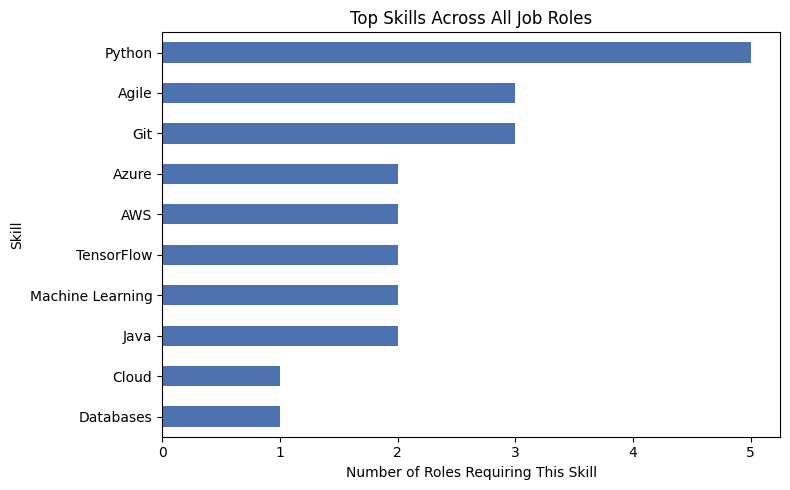

In [6]:
plt.figure(figsize=(8, 5))
top_skills.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top Skills Across All Job Roles")
plt.xlabel("Number of Roles Requiring This Skill")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("outputs/top_skills.png", dpi=150)
plt.show()

## 4. Recommend job roles from a skill set

A small content-based recommender: TF-IDF vectorize each role's skill set,
then rank roles by cosine similarity to a user's own skills.

Skills are pulled from the **cleaned** long-format data (not the raw string
column), so the vocabulary isn't polluted by casing/duplicate inconsistencies.


In [7]:
from dataclasses import dataclass
from typing import List, Tuple


@dataclass(frozen=True)
class Recommendation:
    job_role: str
    skills: str
    match_score: float

    def as_percentage(self) -> str:
        return f"{self.match_score * 100:.1f}%"


class TechStackRecommender:
    # Keeps tokens like "C++", "CI/CD", "Node.js" intact.
    _TOKEN_PATTERN = r"(?u)\b[\w./+-]+\b"

    def __init__(self, long_df: pd.DataFrame, min_skills: int = 3) -> None:
        self.min_skills = min_skills
        self.data = (
            long_df.groupby("job_role")["skill"]
            .apply(lambda skills: " ".join(skills))
            .reset_index()
            .rename(columns={"skill": "skills"})
        )
        self.vectorizer = TfidfVectorizer(token_pattern=self._TOKEN_PATTERN)
        self.item_vectors = self.vectorizer.fit_transform(self.data["skills"])

    def _validate_input(self, user_skills: List[str]) -> None:
        if not isinstance(user_skills, list) or not all(isinstance(s, str) for s in user_skills):
            raise TypeError("user_skills must be a list of strings.")
        meaningful = [s for s in user_skills if s.strip()]
        if len(meaningful) < self.min_skills:
            raise ValueError(
                f"Please provide at least {self.min_skills} skills for accurate matching "
                f"(got {len(meaningful)})."
            )

    def recommend(self, user_skills: List[str], top_n: int = 3) -> List[Recommendation]:
        self._validate_input(user_skills)
        if top_n < 1:
            raise ValueError(f"top_n must be a positive integer (got {top_n}).")

        cleaned = [s.strip() for s in user_skills if s.strip()]
        user_vector = self.vectorizer.transform([" ".join(cleaned)])
        scores = cosine_similarity(user_vector, self.item_vectors).flatten()

        ranked: List[Tuple[int, float]] = sorted(enumerate(scores), key=lambda p: p[1], reverse=True)
        return [
            Recommendation(
                job_role=self.data.iloc[idx]["job_role"],
                skills=self.data.iloc[idx]["skills"],
                match_score=score,
            )
            for idx, score in ranked if score > 0
        ][:top_n]


def print_recommendations(user_skills: List[str], recs: List[Recommendation]) -> None:
    print(f"\nUser skills: {user_skills}")
    if not recs:
        print("\nNo strong matches found. Try adding common skills like 'Python', 'SQL', or 'Cloud Computing'.")
        return
    print(f"\nTop {len(recs)} recommended job roles:\n")
    for rank, rec in enumerate(recs, start=1):
        print(f"  {rank}. {rec.job_role:<25} Match: {rec.as_percentage()}")
        print(f"     Skills: {rec.skills}\n")


recommender = TechStackRecommender(long_df)

In [8]:
user_skills = ["Python", "Cloud Computing", "Automation"]
recommendations = recommender.recommend(user_skills, top_n=3)
print_recommendations(user_skills, recommendations)


User skills: ['Python', 'Cloud Computing', 'Automation']

Top 3 recommended job roles:

  1. Cloud Architect           Match: 40.1%
     Skills: AWS Azure Cloud Computing GCP IaC Networking Security Solution Architecture

  2. Backend Developer         Match: 27.5%
     Skills: Cloud Databases Git Java Microservices Node.js Python REST APIs

  3. Software Engineer         Match: 10.1%
     Skills: Agile Algorithms C++ Data Structures Git Java Python



In [9]:
user_skills = ["Python", "SQL", "Machine Learning", "Statistics"]
recommendations = recommender.recommend(user_skills, top_n=3)
print_recommendations(user_skills, recommendations)


User skills: ['Python', 'SQL', 'Machine Learning', 'Statistics']

Top 3 recommended job roles:

  1. Data Scientist            Match: 64.1%
     Skills: Data Visualization Machine Learning Pandas Python R SQL Scikit-learn Statistics TensorFlow

  2. Machine Learning Engineer Match: 39.6%
     Skills: Computer Vision Deep Learning MLOps Machine Learning NLP PyTorch Python TensorFlow

  3. Software Engineer         Match: 7.4%
     Skills: Agile Algorithms C++ Data Structures Git Java Python



Try it with your own skills — edit the list below and re-run:

In [10]:
your_skills = ["JavaScript", "React", "HTML", "CSS"]
print_recommendations(your_skills, recommender.recommend(your_skills, top_n=3))


User skills: ['JavaScript', 'React', 'HTML', 'CSS']

Top 1 recommended job roles:

  1. Frontend Developer        Match: 64.7%
     Skills: Angular CSS Git HTML Javascript React UI/UX Vue.js Web Development



## 5. Next steps

- Swap the sample dataset for real job-posting data
- Add unit tests for `normalize_skill()`, `to_long_format()`, and `recommend()`
- Turn the recommender into a small Streamlit/Flask demo

See `README.md` for the equivalent standalone scripts (`generate_data.py`,
`clean_skills.py`, `analyze_skills.py`, `recommend.py`) if you'd rather run
this pipeline from the command line instead of a notebook.
